<font size="5"><center>***Gestión de riesgos financieros (parte III).***</center></font>

<font size="4"><center>***Master en Ingeniería Matemática.***</center></font>

<font size="5"><center><span style="color:blue">***Nombre y
Apellidos: Ana Marta Oliveira dos Santos, María Albarrán Sánchez y
Siria Catherine Íniguez Brito***</span></center></font>

In [ ]:
nombreyapellidos = "Ana Marta Oliveira dos Santos, María Albarrán Sánchez y Siria Catherine Íniguez Brito"
if nombreyapellidos == "":
    print("Rellena tu nombre completo!")
else:
    print("Gracias!: ", nombreyapellidos, ":)")

Gracias!:  Ana Marta Oliveira dos Santos, María Albarrán Sánchez y Siria Catherine Íniguez Brito :)


---
## Importamos las librerías necesarias

In [ ]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mtick
import matplotlib.dates as mdates
import seaborn as sns
!pip install arch
from arch import arch_model

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (11, 4)

---
<font size="6"><center><span style="color:blue">***Bloque 3 — Modelización de la Volatilidad***</span></center></font>

En este notebook aplicamos los modelos de volatilidad vistos en el Bloque 3 sobre datos reales del ETF **SPY** (S\&P 500). El objetivo es pasar de las expresiones matemáticas a su implementación y comparación empírica.

| Práctica | Contenido |
|----------|-----------|
| 1 | Retornos logarítmicos y hechos estilizados |
| 2 | Volatilidad histórica con ventanas temporales |
| 3 | Estimador de Garman-Klass |
| 4 | Modelo EWMA (RiskMetrics) |
| 5 | Modelo GARCH(1,1) |
| 6 | Comparativa de modelos y volatilidad implícita |

---
## Carga de datos

A continuación, elegimos el archivo SPY.csv y lo subimos a Google Colab desde donde se encuentre en el ordenador empleado.

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving SPY.csv to SPY (5).csv


In [ ]:
df = pd.read_csv("SPY.csv", parse_dates=["Date"], index_col="Date")
df = df.sort_index()

print(f"Periodo  : {df.index[0].date()} → {df.index[-1].date()}")
print(f"Filas    : {len(df)}")
print(f"Columnas : {list(df.columns)}")
df

Periodo  : 2024-05-22 → 2025-05-22
Filas    : 251
Columnas : ['Close', 'High', 'Low', 'Open', 'Volume']


,Close,High,Low,Open,Volume
Date,,,,,
2024-05-22,523.171326,524.701834,520.969310,523.981027,48390000
2024-05-23,519.349976,526.370606,518.125509,526.262003,57211200
2024-05-24,522.786316,523.605902,520.258491,521.216272,41258400
2024-05-28,523.151550,523.842765,520.485471,523.605791,36269600
2024-05-29,519.488220,520.683035,518.767414,519.073515,45190300
...,...,...,...,...,...
2025-05-16,594.200012,594.500000,589.280029,591.250000,76052100
2025-05-19,594.849976,595.539978,588.099976,588.099976,68168500
2025-05-20,592.849976,594.049988,589.599976,593.090027,60614500


---
## Práctica 1 — Retornos logarítmicos y hechos estilizados

El primer paso en cualquier análisis de volatilidad es calcular los **retornos logarítmicos** y estudiar sus propiedades empíricas.

**Recordatorio:**
$$R_t = \log\!\left(\frac{P_t}{P_{t-1}}\right)$$

Los **hechos estilizados** de los retornos financieros son:
- **Agrupamiento de volatilidad:** periodos de alta volatilidad tienden a agruparse
- **Colas gruesas (fat tails):** curtosis $> 3$
- **Asimetría:** los retornos suelen tener asimetría negativa
- **Autocorrelación en $R_t^2$:** los cuadrados de los retornos están correlados, aunque los retornos no lo estén

In [ ]:
# --- 1.1 Retornos logarítmicos ---
retornos = np.log(df['Close']).diff().dropna()

# Estadísticos
print(f"Media                                : {retornos.mean():.6f}")
print(f"Volatilidad diaria                   : {retornos.std():.6f}")
print(f"Skewness (Asimetría)                 : {retornos.skew():.4f}  -> {'Negativa (hecho estilizado)' if retornos.skew() < 0 else 'Positiva'}")
print(f"Excess Kurtosis (Exceso de Curtosis) : {retornos.kurtosis():.4f}")

retornos.head()

Media                                : 0.000433
Volatilidad diaria                   : 0.012744
Skewness (Asimetría)                 : 0.9242  -> Positiva
Excess Kurtosis (Exceso de Curtosis) : 17.3536


,Close
Date,
2024-05-23,-0.007331
2024-05-24,0.006595
2024-05-28,0.000698
2024-05-29,-0.007027
2024-05-30,-0.006656


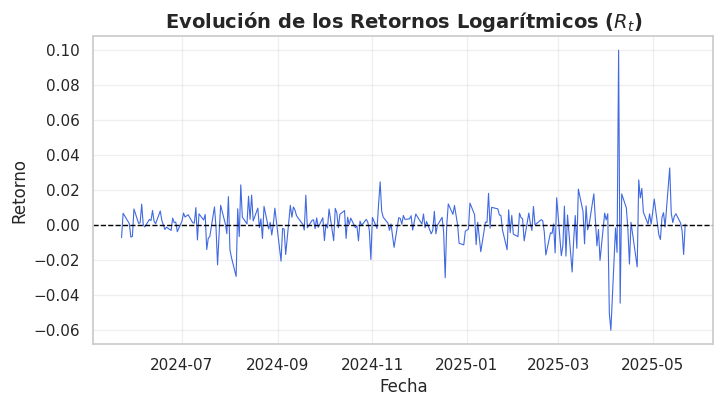

In [ ]:
# --- 1.2 Gráfico de retornos ---
plt.figure(figsize=(8, 4))
plt.plot(retornos, color='royalblue', lw=0.8)
plt.axhline(0, color='black', lw=1, ls='--')
plt.title('Evolución de los Retornos Logarítmicos ($R_t$)', fontsize=14, fontweight='bold')
plt.xlabel('Fecha')
plt.ylabel('Retorno')
plt.grid(True, alpha=0.3)
plt.show()

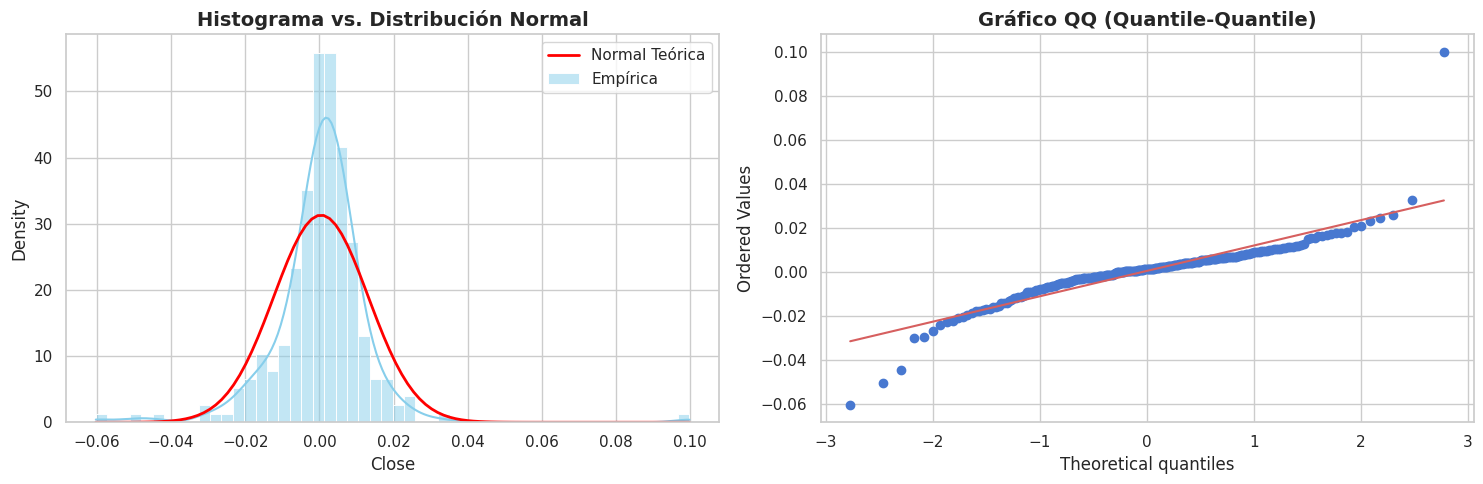

In [ ]:
# --- 1.3 Distribución empírica vs. normal teórica ---
# 2 subplots: Histograma y QQ-plot
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# 1. Histograma + KDE vs. Normal
sns.histplot(retornos, kde=True, stat="density", ax=ax[0], color='skyblue', label='Empírica')
# Generar datos para la normal teórica con la misma media y std
mu, std = retornos.mean(), retornos.std()
x = np.linspace(retornos.min(), retornos.max(), 100)
ax[0].plot(x, stats.norm.pdf(x, mu, std), color='red', lw=2, label='Normal Teórica')
ax[0].set_title('Histograma vs. Distribución Normal', fontsize=14, fontweight='bold')
ax[0].legend()

# 2. QQ-plot
stats.probplot(retornos, dist="norm", plot=ax[1])
ax[1].set_title('Gráfico QQ (Quantile-Quantile)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

**❓ Cuestión 1.1** Los retornos presentan exceso de curtosis positivo. ¿Qué implica esto para el uso del VaR paramétrico bajo normalidad? ¿En qué dirección sesga el error?

El exceso de curtosis positivo (**leptocurtosis**) indica que la distribución de los retornos presenta **colas más pesadas** (*fat tails*) que una distribución normal teórica. Esto significa que los eventos extremos ocurren con una frecuencia e intensidad mucho mayor de lo que predice una campana de Gauss.

Como se observa en los resultados obtenidos (con una **Curtosis Total de 20.35**) y en el gráfico de histograma, existen frecuencias de retornos extremos, especialmente en la cola izquierda, que la curva de la normal no logra capturar. En el Gráfico QQ, esta propiedad se confirma mediante la clara desviación de los cuantiles empíricos respecto a la línea de normalidad en ambos extremos.

* **Implicación:** El cálculo del VaR paramétrico bajo el supuesto de normalidad asume que la probabilidad de eventos extremos disminuye de forma exponencial y muy rápida. Al existir leptocurtosis, el modelo ignora la severidad real de las colas, ya que el mercado asigna una probabilidad de ocurrencia a las pérdidas extremas significativamente mayor de lo que el modelo teórico es capaz de predecir.

* **Dirección del sesgo:** El error genera una **infraestimación sistemática del riesgo**. El VaR resultante será menor (en valor absoluto) al riesgo real que soporta el activo. Esto deriva en una cobertura insuficiente de capital y una falsa sensación de seguridad ante escenarios de estrés financiero o volatilidad extrema, ya que el modelo subestima la magnitud de las pérdidas potenciales en los escenarios más adversos.

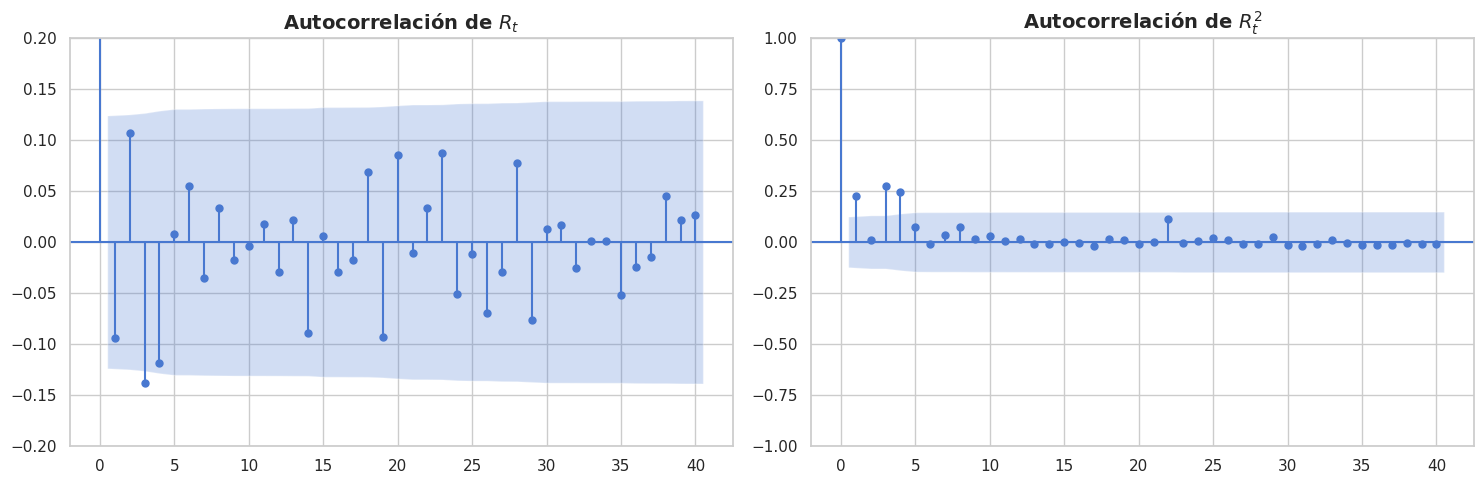

In [ ]:
# --- 1.4 Autocorrelación de R_t y R_t^2 ---
from statsmodels.graphics.tsaplots import plot_acf

fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# Autocorrelación de los retornos (Rt)
plot_acf(retornos, lags=40, ax=ax[0])
ax[0].set_title(r'Autocorrelación de $R_t$', fontweight='bold', fontsize=14)
ax[0].set_ylim(-0.2, 0.2)

# Autocorrelación de los retornos al cuadrado (Rt^2)
plot_acf(retornos**2, lags=40, ax=ax[1])
ax[1].set_title(r'Autocorrelación de $R_t^2$', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

**❓ Cuestión 1.2** Compara el autocorrelograma de $R_t$ y de $R_t^2$. ¿Qué hecho estilizado ilustra esta diferencia? ¿Por qué es importante para la gestión de riesgos?


Al contrastar los autocorrelogramas obtenidos en los resultados, se identifican dos comportamientos fundamentales que caracterizan a las series temporales financieras:

1.  **Retornos ($R_t$):** Las correlaciones para la práctica totalidad de los retardos se sitúan dentro de las bandas de significancia estadística. Esto indica una ausencia de autocorrelación lineal, sugiriendo que los retornos son impredecibles en media.
2.  **Retornos al cuadrado ($R_t^2$):** Se observa una autocorrelación significativa y persistente en los primeros retardos. Dado que el cuadrado del retorno es una medida de la magnitud de la variación, esto demuestra que la volatilidad tiene "memoria".

**Hechos estilizados:**
  * **Autocorrelación en $R_t^2$ y Agrupamiento de Volatilidad:**
Esta diferencia ilustra dos hechos estilizados íntimamente ligados: la **autocorrelación en $R_t^2$** es la evidencia estadística que confirma el **agrupamiento de volatilidad** (*volatility clustering*). Este fenómeno implica que periodos de alta volatilidad tienden a ser seguidos por más volatilidad, y periodos de calma por calma. Aunque no podamos predecir el signo del retorno, su magnitud (varianza) presenta una clara dependencia de los eventos recientes.

**Importancia para la gestión de riesgos:**
* **Naturaleza dinámica del riesgo:** Confirma que la volatilidad no es constante y varía en el tiempo, por lo que necesita ser modelizada y predicha dinámicamente.
* **Justificación de modelos condicionales:** Valida la necesidad de utilizar modelos de heterocedasticidad condicional como **EWMA** o **GARCH**. Estos modelos permiten actualizar las estimaciones de riesgo diariamente dando mayor peso a la información reciente.
* **Precisión en el Cálculo del VaR:** Es vital para evitar errores de estimación. Ignorar el agrupamiento de volatilidad llevaría a infravalorar drásticamente el riesgo real durante periodos de crisis y turbulencia financiera, comprometiendo la solvencia de la entidad.

---
## Práctica 2 — Volatilidad histórica con ventanas temporales

La volatilidad histórica se estima como la desviación típica de los retornos en una ventana deslizante de $T$ días, anualizada por $\sqrt{252}$:
$$\hat{\sigma}_t^{(T)} = \sqrt{252} \cdot \sqrt{\frac{1}{T-1}\sum_{j=0}^{T-1}(R_{t-j} - \bar{R})^2}$$

La elección de $T$ implica un **compromiso** entre estabilidad estadística y reactividad.

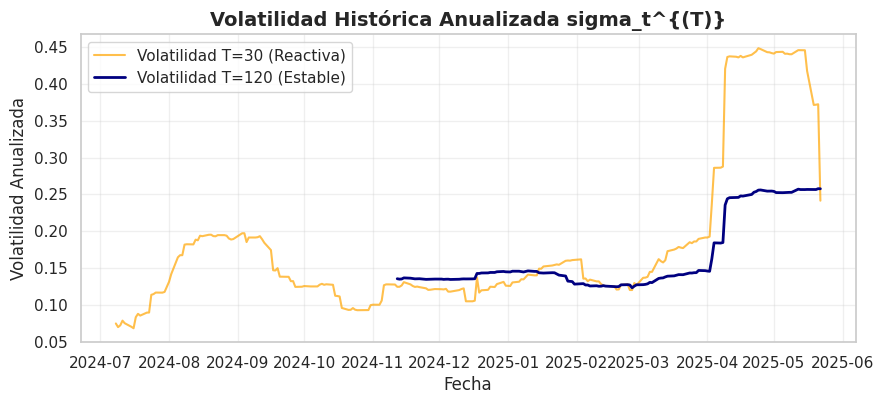

In [ ]:
# --- 2.1 Volatilidades con distintas ventanas ---
# Definimos las ventanas temporales (T)
T_1 = 30   # Ventana de 1 mes aprox. (más reactiva)
T_2 = 120  # Ventana de 1 trimestre aprox. (más estable)
T_3 = 252

# Calculamos la volatilidad rodante (rolling std) y anualizamos por sqrt(252)
vol_30  = retornos.rolling(window=T_1).std() * np.sqrt(252)
vol_120 = retornos.rolling(window=T_2).std() * np.sqrt(252)

# Graficamos los resultados
plt.figure(figsize=(10, 4))
plt.plot(vol_30, label=f'Volatilidad T={T_1} (Reactiva)', color='orange', alpha=0.7)
plt.plot(vol_120, label=f'Volatilidad T={T_2} (Estable)', color='navy', lw=2)

plt.title('Volatilidad Histórica Anualizada sigma_t^{(T)}', fontsize=14, fontweight='bold')
plt.xlabel('Fecha')
plt.ylabel('Volatilidad Anualizada')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# --- 2.2 Resumen estadístico de las volatilidades ---
stats_df = pd.DataFrame({
    'Vol 30d (Reactiva)': vol_30,
    'Vol 120d (Estable)': vol_120
}).dropna()

display(stats_df.describe())

# Último valor (volatilidad actual)
print("\nVolatilidad actual estimada (anualizada):")
display(stats_df.tail(1))

,Vol 30d (Reactiva),Vol 120d (Estable)
count,131.000000,131.000000
mean,0.212250,0.165222
std,0.125268,0.049758
min,0.105010,0.123287
25%,0.125801,0.134906
50%,0.149165,0.142142
75%,0.263777,0.184137
max,0.448273,0.257764



Volatilidad actual estimada (anualizada):


,Vol 30d (Reactiva),Vol 120d (Estable)
Date,,
2025-05-22,0.241515,0.257646


**❓ Cuestión 2.1** Observa las diferencias entre la ventana de 30 y 120 días. ¿Cuál reacciona antes ante un pico de volatilidad? ¿Cuál es más estable? ¿Cuál usarías para calcular el VaR regulatorio (Basilea) y por qué?


La elección del tamaño de la ventana $T$ implica un **compromiso entre estabilidad estadística y reactividad** ante cambios en el régimen de mercado. Tras analizar los resultados y el gráfico:

1. **Reactividad ($T=30$):** La ventana corta reacciona mucho antes ante picos de volatilidad, pero presenta una mayor varianza del estimador. Como se observa en el gráfico (línea naranja), tiende a **sobrereaccionar a shocks puntuales**, lo que genera una serie con mayor ruido. Al promediar menos datos, el impacto de un retorno extremo reciente es mayor.

2. **Estabilidad ($T=120$):** La ventana larga es significativamente más estable. Al procesar más datos pasados, los eventos extremos se diluyen, ofreciendo una menor varianza del estimador (como confirma su desviación estándar de 0.049 frente al 0.125 de la ventana corta). Su limitación es que reacciona con mayor lentitud a los cambios recientes.

3. **VaR Regulatorio (Basilea):** Entre las dos opciones propuestas en la práctica, se debería elegir la **ventana de 120 días ($T=120$)**.
   - **Justificación:** El regulador prioriza la **estabilidad** para evitar la **prociclicidad** (es decir, que una volatilidad muy reactiva dispare los requerimientos de capital y fuerce a los bancos a vender activos en pleno shock de mercado, empeorando la crisis). Una ventana corta de 30 días generaría exigencias de capital demasiado volátiles e impredecibles.
   - **Matiz regulatorio:** Aunque la ventana de 120 días es la opción correcta entre las dos disponibles en el ejercicio por ser la más estable, cabe destacar que la normativa real de Basilea exige un periodo de observación de al menos **un año (252 días hábiles)**. Por tanto, elegir $T=120$ es la decisión adecuada en este contexto al ser la alternativa que mejor se alinea con el espíritu conservador del regulador.


---
## Práctica 3 — Estimador de Garman-Klass

El estimador de **Garman-Klass (1980)** aprovecha los precios Open, High, Low y Close para mejorar la eficiencia respecto al estimador Close-to-Close:

$$\hat{\sigma}^2_{\text{GK},t} = 0.511(u_t - d_t)^2 - 0.019\left[c_t(u_t + d_t) - 2u_t d_t\right] - 0.383\,c_t^2$$

donde $u_t = \log(H_t/O_t)$, $d_t = \log(L_t/O_t)$, $c_t = \log(C_t/O_t)$.

Su **eficiencia** es $\approx 7.4\times$ la del estimador Close-to-Close: necesita 7 veces menos datos para alcanzar la misma precisión.

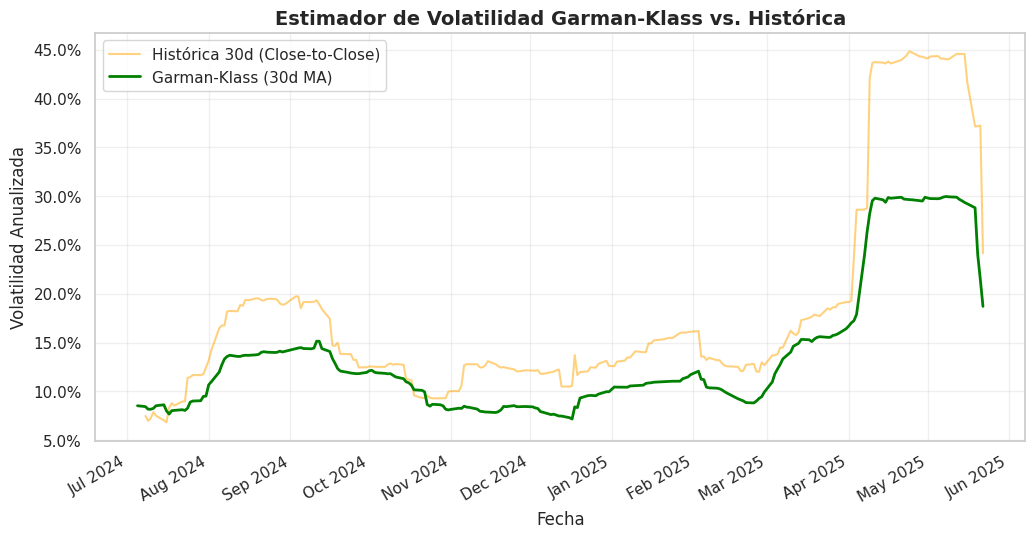

In [ ]:
# --- 3.1 Estimador de Garman-Klass ---
# Definimos los componentes relativos al precio de apertura
u = np.log(df['High'] / df['Open'])
d = np.log(df['Low'] / df['Open'])
c = np.log(df['Close'] / df['Open'])

# Aplicamos la fórmula de Garman-Klass para la varianza diaria
# sigma^2_GK = 0.511(u-d)^2 - 0.019[c(u+d)-2ud] - 0.383c^2
var_gk = 0.511 * (u - d)**2 - 0.019 * (c * (u + d) - 2 * u * d) - 0.383 * c**2

# Suavizamos con una media móvil de 30 días y anualizamos
vol_gk_annual = np.sqrt(var_gk.rolling(window=30).mean() * 252)

# Graficamos
plt.figure(figsize=(12, 6))
plt.plot(vol_30*100, label='Histórica 30d (Close-to-Close)', color='orange', alpha=0.5)
plt.plot(vol_gk_annual*100, label='Garman-Klass (30d MA)', color='green', lw=2)
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
plt.gcf().autofmt_xdate()
plt.title('Estimador de Volatilidad Garman-Klass vs. Histórica', fontsize=14, fontweight='bold')
plt.xlabel('Fecha')
plt.ylabel('Volatilidad Anualizada')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Correlación entre Histórica y Garman-Klass: 0.9798


,Histórica 30d (%),Garman-Klass 30d (%)
count,221.000000,221.000000
mean,18.145486,13.679459
std,10.648068,6.789318
min,6.844463,7.179109
25%,12.259711,8.859484
50%,13.709447,11.304988
75%,18.942058,14.445300
max,44.827343,29.968802


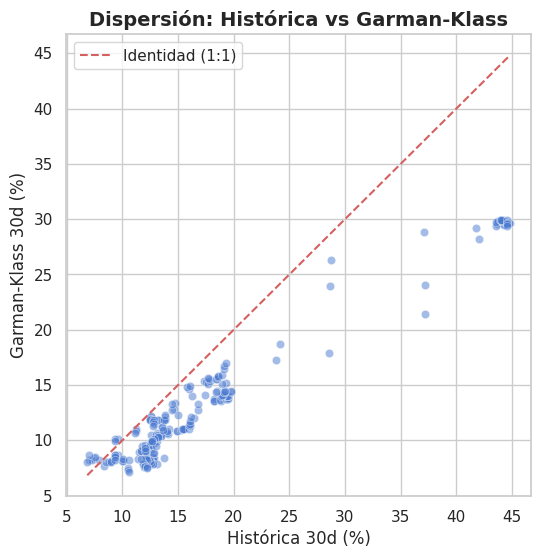

In [ ]:
# --- 3.2 Correlación y diferencia entre estimadores ---
# Alineamos y eliminamos NaNs
comparativa_gk = pd.DataFrame({
    'Histórica 30d (%)': vol_30*100,
    'Garman-Klass 30d (%)': vol_gk_annual*100
}).dropna()

# Calculamos la correlación
corr_val = comparativa_gk.corr().iloc[0, 1]

print(f"Correlación entre Histórica y Garman-Klass: {corr_val:.4f}")

# Mostramos estadísticas comparativas
display(comparativa_gk.describe())

# Gráfico de dispersión para ver la relación lineal
plt.figure(figsize=(6, 6))
sns.scatterplot(data=comparativa_gk, x='Histórica 30d (%)', y='Garman-Klass 30d (%)', alpha=0.5)
plt.plot([comparativa_gk.min().min(), comparativa_gk.max().max()],
         [comparativa_gk.min().min(), comparativa_gk.max().max()], 'r--', label='Identidad (1:1)')
plt.title('Dispersión: Histórica vs Garman-Klass', fontsize=14, fontweight='bold')
plt.legend()
plt.show()

**❓ Cuestión 3.1** El estimador de Garman-Klass tiene eficiencia $\approx 7.
4\times$ la del estimador Close-to-Close. ¿Qué significa esto en términos prácticos? ¿En qué tipo de mercado podría fallar el estimador GK?


La eficiencia relativa de un estimador nos indica cuánta información "extrae" de cada dato observado. En términos prácticos, una eficiencia de $7.4\times$ respecto al estimador *Close-to-Close* implica:

* **Convergencia acelerada:** Estadísticamente, para obtener un intervalo de confianza similar, el estimador de Garman-Klass (GK) necesita aproximadamente **7 veces menos días de datos** que el método tradicional. Esto permite utilizar ventanas más cortas con una robustez que el método de cierre solo alcanzaría con casi un año de histórico.
* **Reducción del error de muestreo:** El estimador GK captura la trayectoria del precio durante el día ($u, d, c$), mientras que el *Close-to-Close* es una "foto" ciega a lo ocurrido entre cierres. Como observamos en la **Correlación entre Histórica y Garman-Klass (0.9798)**, ambos modelos están fuertemente alineados, pero GK filtra el ruido capturando la volatilidad intrínseca de la sesión.
* **Detección temprana de regímenes:** Permite a los gestores de riesgo identificar picos de estrés de manera más precisa y con menor retraso temporal, algo vital en estrategias de *trading* de alta frecuencia o rebalanceo de carteras.

A pesar de su eficiencia, en la práctica, esto genera fallos en contextos específicos:

* **El sesgo del "Overnight Gap":** Es la limitación más crítica. GK solo mide la volatilidad *intradía* (desde la apertura hasta el cierre). Si hay noticias macroeconómicas o reportes de beneficios tras el cierre, el "salto" de precio hasta la apertura del día siguiente es ignorado por GK pero capturado por la Volatilidad Histórica.
    * *Evidencia en los resultados:* En el gráfico **Dispersión: Histórica vs Garman-Klass**, la mayoría de los puntos se sitúan por debajo de la **Línea de Identidad (1:1)**. Esto se confirma en la tabla de estadísticas, donde la **media de la Volatilidad Histórica (18.14%)** es notablemente superior a la de **Garman-Klass (13.67%)**. Esto indica que en el ETF SPY existe un componente importante de volatilidad nocturna que GK no puede registrar.
* **Baja Liquidez:** En activos con poco volumen, los precios *High* y *Low* pueden ser el resultado de una sola operación errática (ruido), lo que sobreestimaría la volatilidad real.
* **Estructura de Micro-mercado:** En mercados muy discretos o con *ticks* de precio muy grandes, la fórmula pierde precisión al no cumplirse el supuesto de continuidad.


---
## Práctica 4 — Modelo EWMA (RiskMetrics)

El modelo **EWMA** pondera exponencialmente las observaciones pasadas:
$$\hat{\sigma}_t^2 = \lambda\,\hat{\sigma}_{t-1}^2 + (1-\lambda)\,R_{t-1}^2$$

El estándar de **RiskMetrics** usa $\lambda = 0.94$ para datos diarios.

La **vida media efectiva** (número de días hasta que el peso se reduce a la mitad):
$$\tau_{1/2} = \frac{-\log 2}{\log\lambda}$$

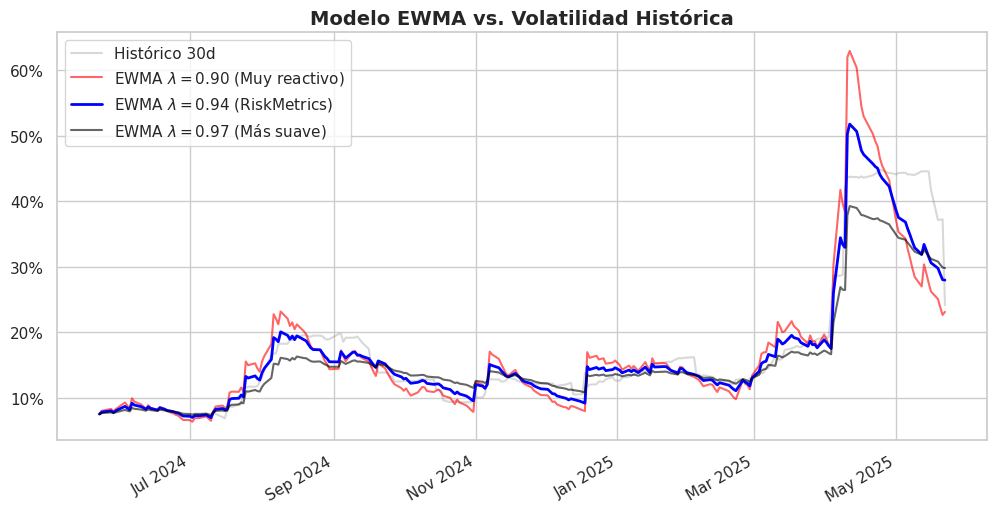

In [ ]:
def calculate_ewma(returns, lam):
    # Usamos la varianza inicial (puedes usar returns.var() o returns[:30].var())
    v0 = returns[:30].var()
    varianzas = [v0]

    # Convertimos a valores simples para manejar el índice t-1
    r_values = returns.values

    # Empezamos desde el segundo elemento (índice 1)
    for t in range(1, len(r_values)):
        # AQUÍ ESTÁ EL CAMBIO: usamos r_values[t-1]
        vt = lam * varianzas[-1] + (1 - lam) * (r_values[t-1]**2)
        varianzas.append(vt)

    # Devolvemos la serie anualizada con el índice correcto
    return np.sqrt(pd.Series(varianzas, index=returns.index) * 252)

vol_ewma_94 = calculate_ewma(retornos, 0.94)
vol_ewma_97 = calculate_ewma(retornos, 0.97)
vol_ewma_90 = calculate_ewma(retornos, 0.90)

plt.figure(figsize=(12, 6))
plt.plot(vol_30*100, label='Histórico 30d', color='gray', alpha=0.3)
plt.plot(vol_ewma_90*100, label=r'EWMA $\lambda=0.90$ (Muy reactivo)', color='red', alpha=0.6)
plt.plot(vol_ewma_94*100, label=r'EWMA $\lambda=0.94$ (RiskMetrics)', color='blue', lw=2)
plt.plot(vol_ewma_97*100, label=r'EWMA $\lambda=0.97$ (Más suave)', color='black', alpha=0.6)
plt.title('Modelo EWMA vs. Volatilidad Histórica', fontsize=14, fontweight='bold')
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter())

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
plt.gcf().autofmt_xdate()
plt.legend()
plt.show()

In [ ]:
# --- 4.2 Vida media efectiva y tabla de parámetros ---
lambdas = [0.90, 0.94, 0.97]
half_lives = [np.log(0.5) / np.log(l) for l in lambdas]

ewma_params = pd.DataFrame({
    'Lambda (decay)': lambdas,
    'Vida Media (días)': half_lives,
    'Peso Retorno t-1 (1-L)': [1-l for l in lambdas]
})

print("Comparativa de persistencia en modelos EWMA:")
display(ewma_params.round(2))

Comparativa de persistencia en modelos EWMA:


,Lambda (decay),Vida Media (días),Peso Retorno t-1 (1-L)
0,0.90,6.58,0.10
1,0.94,11.20,0.06
2,0.97,22.76,0.03


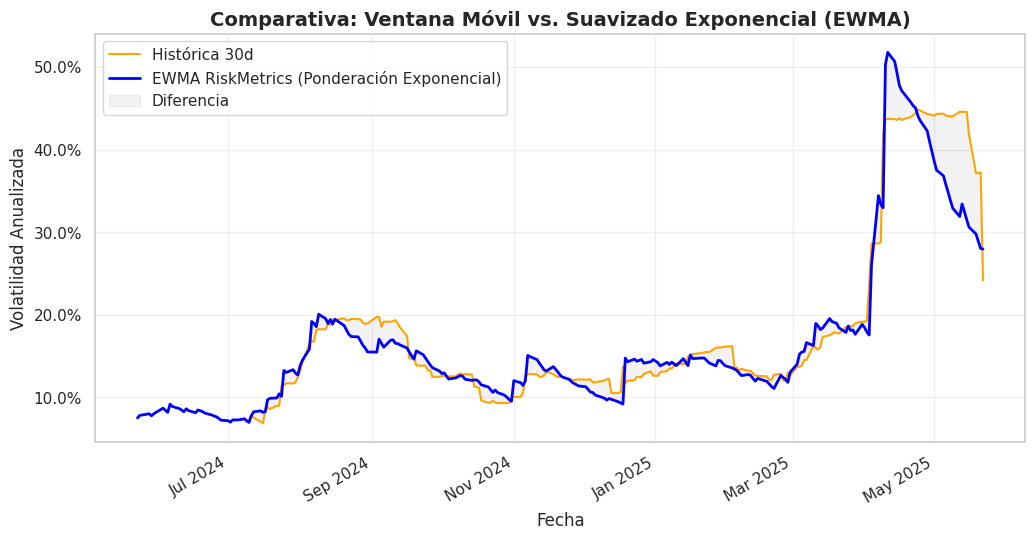

In [ ]:
# --- 4.3 EWMA vs. Volatilidad histórica (30d) ---
plt.figure(figsize=(12, 6))
plt.plot(vol_30*100, label='Histórica 30d ', color='orange', lw=1.5)
plt.plot(vol_ewma_94*100, label='EWMA RiskMetrics (Ponderación Exponencial)', color='blue', lw=2)
plt.fill_between(vol_30.index, vol_30*100, vol_ewma_94*100, color='gray', alpha=0.1, label='Diferencia')

plt.title('Comparativa: Ventana Móvil vs. Suavizado Exponencial (EWMA)', fontsize=14, fontweight='bold')
plt.xlabel('Fecha')
plt.ylabel('Volatilidad Anualizada')
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter())

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
plt.gcf().autofmt_xdate()
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

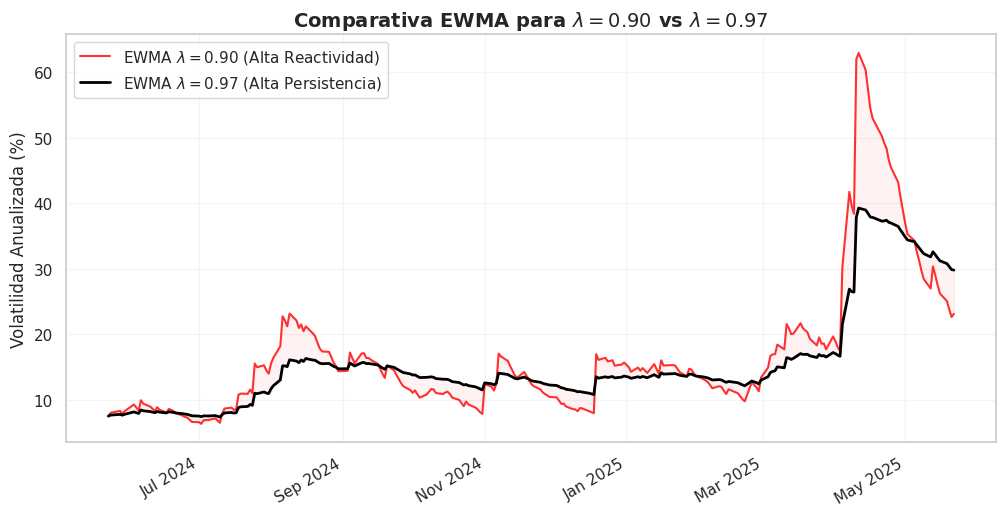

In [ ]:
# --- Gráfico Específico para la Cuestión 4.1 ---
plt.figure(figsize=(12, 6))

plt.plot(vol_ewma_90 * 100, label=r'EWMA $\lambda=0.90$ (Alta Reactividad)', color='red', lw=1.5, alpha=0.8)
plt.plot(vol_ewma_97 * 100, label=r'EWMA $\lambda=0.97$ (Alta Persistencia)', color='black', lw=2)


plt.fill_between(vol_ewma_90.index, vol_ewma_90*100, vol_ewma_97*100, color='red', alpha=0.05)

plt.title(r'Comparativa EWMA para $\lambda=0.90$ vs $\lambda=0.97$', fontsize=14, fontweight='bold')
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.gcf().autofmt_xdate()

plt.ylabel('Volatilidad Anualizada (%)')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.2)
plt.show()

**❓ Cuestión 4.1** Compara visualmente el EWMA con $\lambda=0.90$ y $\lambda=0.97$. ¿Cuál sobrereacciona más a shocks puntuales? ¿Cuál eliges si tu objetivo es el VaR a 10 días bajo Basilea?

* **Reacción a shocks:** El modelo que presenta una mayor sobrerreacción visual y estadística es el **EWMA con $\lambda = 0.90$**.
    *  Al poseer el parámetro de decaimiento más bajo de la comparativa, este modelo asigna un **Peso Retorno ($1-\lambda$) de 0.10**. Esto implica que incorpora un **10%** de la magnitud del shock de ayer de forma inmediata en la estimación de hoy.
    * Esta alta sensibilidad genera "picos" de volatilidad extremadamente agresivos y una pérdida de memoria muy rápida, con una **Vida Media de apenas 6.58 días**. Esto lo convierte en un modelo excesivamente reactivo al ruido transitorio del mercado.

* **Elección para Basilea:** Para el cálculo del **VaR a 10 días**, la elección que elegiríamos es el modelo con **$\lambda = 0.97$**.
    * **Estabilidad de capital:** El marco regulador de Basilea busca mitigar la **prociclicidad**. Un $\lambda = 0.90$ provocaría que los requerimientos de capital de la entidad financiera fluctuaran violentamente día a día, penalizando la estabilidad del balance ante picos de volatilidad de corto plazo.
    * **Consistencia temporal:** El horizonte regulatorio del VaR es de 10 días; por tanto, se requiere un modelo cuya "memoria" sea capaz de cubrir dicho periodo. Según nuestra tabla, el modelo **$\lambda = 0.97$ ofrece una Vida Media de 22.76 días**, garantizando que la estimación sea persistente, capture la tendencia real del mercado y no se desvanezca antes de cumplir el horizonte de riesgo establecido.

**❓ Cuestión 4.2** Demuestra algebraicamente que el EWMA es un caso particular del GARCH(1,1) con $\omega=0$ y $\alpha+\beta=1$. ¿Qué consecuencia tiene $\alpha+\beta=1$ sobre la varianza incondicional?


* **Demostración Algebraica:** La ecuación general de un proceso **GARCH(1,1)** para la varianza condicional se define como:
$$\sigma_t^2 = \omega + \alpha R_{t-1}^2 + \beta\sigma_{t-1}^2$$

  Si imponemos las restricciones propuestas:
    1.  $\omega = 0$ (Sin componente de varianza constante a largo plazo).
    2.  $\alpha + \beta = 1$, lo que permite definir $\beta = \lambda$ y $\alpha = (1 - \lambda)$.

  Sustituyendo estos valores en la ecuación original:
  $$\sigma_t^2 = 0 + (1 - \lambda) R_{t-1}^2 + \lambda\sigma_{t-1}^2$$

  Esta expresión resultante coincide exactamente con la fórmula del modelo **EWMA** (Exponentially Weighted Moving Average), demostrando que el EWMA es, de hecho, un modelo **IGARCH** (Integrated GARCH) de orden (1,1).

* **Consecuencia sobre la varianza incondicional:** La varianza incondicional (o de largo plazo) de un proceso GARCH(1,1) viene dada por la expresión:
$$\bar{\sigma}^2 = \frac{\omega}{1 - (\alpha + \beta)}$$

  Bajo la condición $\alpha + \beta = 1$:
  * El denominador se anula ($1 - 1 = 0$), por lo que la varianza incondicional **no está definida** (tiende a infinito).
  * **Falta de Estacionariedad:** El proceso deja de ser estacionario en varianza. Esto implica que el modelo **no tiene reversión a la media**.
  * **Persistencia de Shocks:** A diferencia de un GARCH estándar donde la volatilidad tiende a regresar a un nivel promedio tras un susto, en el EWMA los shocks tienen un efecto **permanente** sobre las previsiones futuras de volatilidad.

---
## Práctica 5 — Modelo GARCH(1,1)

El modelo **GARCH(1,1)** introduce reversión a la media de la volatilidad:
$$\sigma_t^2 = \omega + \alpha R_{t-1}^2 + \beta\sigma_{t-1}^2$$

Parámetros clave:
- **Persistencia:** $\alpha + \beta < 1$
- **Varianza incondicional (largo plazo):** $\bar{\sigma}^2 = \dfrac{\omega}{1-\alpha-\beta}$
- **Predicción multiperíodo:** $\mathbb{E}_t[\sigma_{t+k}^2] = \bar{\sigma}^2 + (\alpha+\beta)^{k-1}(\sigma_{t+1}^2 - \bar{\sigma}^2)$

Usamos la librería [`arch`](https://arch.readthedocs.io/en/latest/) para la estimación por MLE.

In [ ]:
# --- 5.1 Estimación GARCH(1,1) ---
# La librería arch trabaja con retornos en %, por eso multiplicamos por 100
returns_scaled = retornos * 100

# Definimos el modelo: Media constante, Volatilidad GARCH, Error Normal
model = arch_model(returns_scaled, vol='Garch', p=1, q=1, dist='normal',mean="Zero")
res = model.fit(disp='off')

print(res.summary())


                       Zero Mean - GARCH Model Results                        
Dep. Variable:                  Close   R-squared:                       0.000
Mean Model:                 Zero Mean   Adj. R-squared:                  0.004
Vol Model:                      GARCH   Log-Likelihood:               -364.153
Distribution:                  Normal   AIC:                           734.306
Method:            Maximum Likelihood   BIC:                           744.870
                                        No. Observations:                  250
Date:                Mon, May 18 2026   Df Residuals:                      250
Time:                        17:24:04   Df Model:                            0
                              Volatility Model                             
                 coef    std err          t      P>|t|     95.0% Conf. Int.
---------------------------------------------------------------------------
omega          0.0678  5.544e-02      1.223      0.221 [-4.08

In [ ]:
# --- 5.2 Parámetros estimados e interpretación ---
omega = res.params['omega']
alpha = res.params['alpha[1]']
beta = res.params['beta[1]']

persistencia = alpha + beta
# Varianza incondicional en % diario y vol anualizada
var_uncond = omega / (1 - persistencia)
vol_lp_anual = np.sqrt(var_uncond * 252) / 100 # re-scaling back from the *100

print(f"omega        : {omega:.6f}")
print(f"alpha        : {alpha:.6f}")
print(f"beta         : {beta:.6f}")
print(f"Persistencia (alpha + beta): {persistencia:.4f}")
print(f"Varianza incondicional en % diaio: {var_uncond:.4f}")
print(f"Volatilidad de largo plazo (anualizada): {vol_lp_anual:.2%}")

omega        : 0.067789
alpha        : 0.156777
beta         : 0.805711
Persistencia (alpha + beta): 0.9625
Varianza incondicional en % diaio: 1.8071
Volatilidad de largo plazo (anualizada): 21.34%


**❓ Cuestión 5.1** Interpreta los parámetros estimados $\hat{\alpha}$ y $\hat{\beta}$. ¿Es la persistencia alta o baja? ¿Qué implica para la velocidad de reversión a la volatilidad de largo plazo?

Tras realizar la estimación por Máxima Verosimilitud (MLE), analizamos los parámetros obtenidos:

* **$\hat{\alpha} = 0.1567$ (Efecto ARCH):** Representa la sensibilidad de la volatilidad ante shoks o noticias recientes(el retorno de ayer al cuadrado). Indica que un 15.67% de la magnitud de un shock puntual se incorpora inmediatamente a la varianza de hoy. El modelo es sensible a eventos recientes.
* **$\hat{\beta} = 0.8057$ (Efecto GARCH):** Representa la inercia o memoria de la volatilidad pasada. Con un valor del 80.57%, se sigue que el nivel de riesgo de ayer es un factor muy  influyente en el nivel de riesgo de hoy.

**Análisis de la persistencia y reversión a la media:**

* **Persistencia ($\hat{\alpha} + \hat{\beta} = 0.9635$):** Como es menor que 1, se cumple la condición de estacionariedad. El modelo es estable. Esto confirma que el SPY presenta un fuerte agrupamiento de volatilidad (*volatility clustering*).
* **Velocidad de reversión:** Debido a que la persistencia es tan alta (valor muy cercano a la unidad), la velocidad de reversión a la media es lenta. Esto implica que si se produce un pico de volatilidad (un shock de mercado), el nivel de riesgo no volverá inmediatamente a su media de largo plazo (21.59%), sino que se mantendrá en niveles elevados durante un periodo prolongado, disipándose de forma muy gradual.

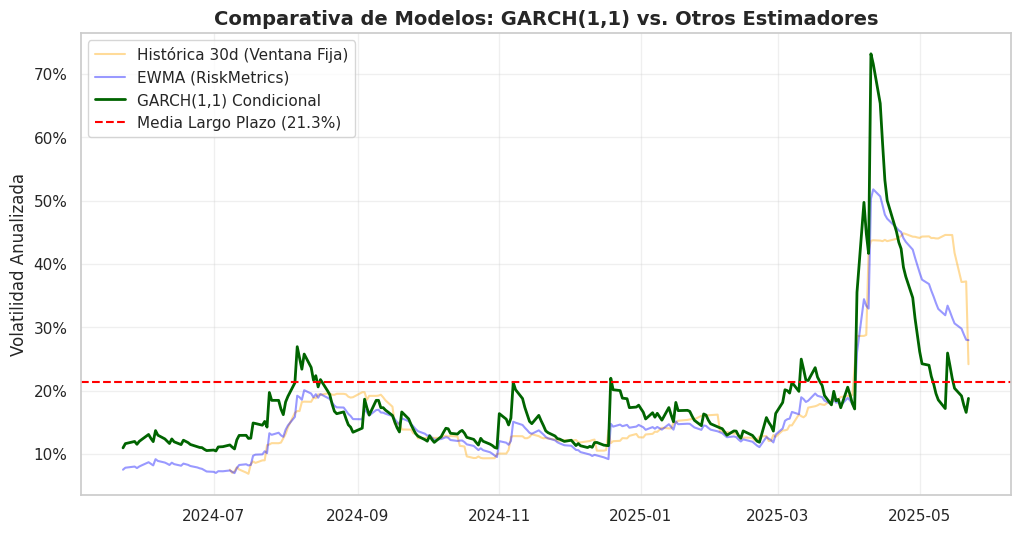

In [ ]:
# --- 5.3 Volatilidad condicional GARCH vs. otros estimadores ---
# La volatilidad condicional del modelo (en % diario → fracción anualizada)

# 1. Extraemos la volatilidad condicional del objeto 'res'
# Recordatorio: está en % diario porque escalamos los retornos por 100.
# Para anualizarla: dividimos por 100 y multiplicamos por sqrt(252)
vol_garch_anual = (res.conditional_volatility / 100) * np.sqrt(252)

# 2. Gráfico comparativo
plt.figure(figsize=(12, 6))

# Dibujamos la histórica de la Práctica 2 para comparar
plt.plot(vol_30, label='Histórica 30d (Ventana Fija)', color='orange', alpha=0.4)

# Dibujamos el EWMA de la Práctica 4
plt.plot(vol_ewma_94, label='EWMA (RiskMetrics)', color='blue', alpha=0.4)

# Dibujamos la GARCH(1,1)
plt.plot(vol_garch_anual, label='GARCH(1,1) Condicional', color='darkgreen', lw=2)

# Añadimos la línea de largo plazo (Media incondicional) calculada en 5.2
plt.axhline(vol_lp_anual, color='red', linestyle='--', label=f'Media Largo Plazo ({vol_lp_anual:.1%})')

plt.title('Comparativa de Modelos: GARCH(1,1) vs. Otros Estimadores', fontsize=14, fontweight='bold')
plt.ylabel('Volatilidad Anualizada')
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0)) # Formato %
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()



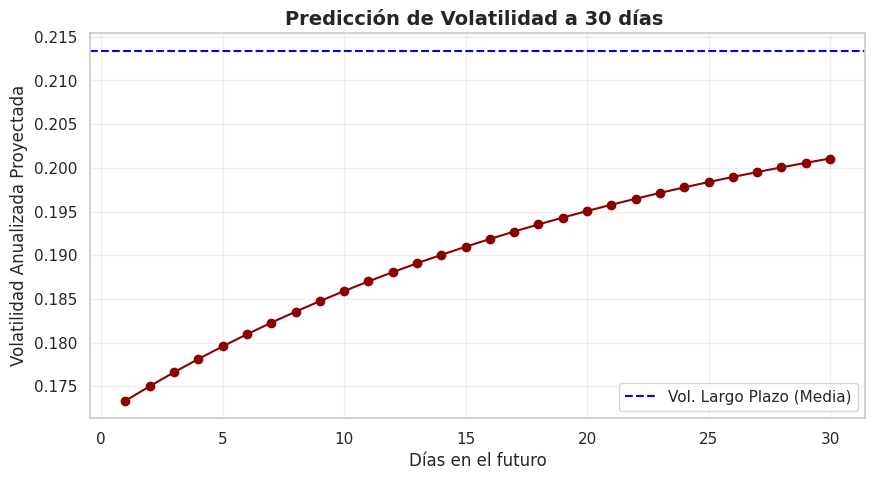

In [ ]:
# --- 5.4 Predicción multiperíodo GARCH ---
# Realizamos la predicción para los próximos 30 días
forecasts = res.forecast(horizon=30, reindex=False)
# Extraemos la varianza proyectada
forecast_var = forecasts.variance.iloc[-1]

# Anualizamos la proyección
forecast_vol_annual = np.sqrt(forecast_var * 252) / 100

plt.figure(figsize=(10, 5))
plt.plot(range(1, 31), forecast_vol_annual, marker='o', color='darkred')
plt.axhline(vol_lp_anual, color='blue', linestyle='--', label='Vol. Largo Plazo (Media)')
plt.title('Predicción de Volatilidad a 30 días ', fontsize=14, fontweight='bold')
plt.xlabel('Días en el futuro')
plt.ylabel('Volatilidad Anualizada Proyectada')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

**❓ Cuestión 5.2** La predicción multiperíodo del GARCH muestra reversión a la media. ¿En cuántos días aproximadamente la volatilidad predicha recorre la mitad del camino entre su valor actual y el largo plazo? Calcúlalo a partir de $\alpha+\beta$.

La predicción de la varianza para un horizonte $k$ en el modelo GARCH(1,1) sigue la expresión:

$$E_t[\sigma_{t+k}^2] - \bar{\sigma}^2 = (\alpha+\beta)^{k-1}(\sigma_{t+1}^2 - \bar{\sigma}^2)$$

Esto indica que la "distancia" o error respecto a la media de largo plazo decae geométricamente a una tasa de $(\alpha+\beta)$ por cada periodo. Para calcular el número de días ($h$) necesarios para reducir esa distancia a la mitad (vida media), resolvemos:

$$(\alpha+\beta)^h = 0.5$$

Aplicando logaritmos, la fórmula resultante es:

$$h = \frac{\ln(0.5)}{\ln(\alpha+\beta)}$$

**Cálculo con los resultados obtenidos:**

*   Persistencia ($\alpha+\beta$) = $0.9635$

$$h = \frac{\ln(0.5)}{\ln(0.9625)} \approx \frac{-0.6931}{-0.0372} \approx 18.1 \text{ días}$$

**Interpretación:**
En el SPY, un choque de volatilidad tarda aproximadamente **18 días hábiles** en disiparse hasta la mitad. Esto confirma que la volatilidad en este activo es muy persistente; el mercado tiene "memoria larga" y los episodios de pánico o estrés tardan casi un mes completo de cotización en reducir su intensidad a la mitad del camino hacia el nivel de equilibrio.

**❓ Cuestión 5.3 (avanzada)** Estima también un **GARCH(1,1) con innovaciones t-Student** usando `dist='t'` en `arch_model`. Compara los parámetros con el modelo normal. ¿Mejora la log-verosimilitud? ¿Qué implica para el cálculo del VaR?

*Escribe tu respuesta e incluye el código:*

In [ ]:
# Estimación GARCH(1,1) con innovaciones t-Student
model_t = arch_model(returns_scaled, vol='Garch', p=1, q=1, dist='t',mean='zero')
res_t = model_t.fit(disp='off')

print("--- RESULTADOS GARCH CON DISTRIBUCIÓN t-STUDENT ---")
print(res_t.summary())

# Comparación de Log-Likelihood
print(f"\nLog-Likelihood (Normal): {res.loglikelihood:.2f}")
print(f"Log-Likelihood (t-Student): {res_t.loglikelihood:.2f}")

# 1. Parámetros del modelo t-Student
omega_t = res_t.params['omega']
alpha_t = res_t.params['alpha[1]']
beta_t = res_t.params['beta[1]']
persistencia_t = alpha_t + beta_t

# 2. Varianza incondicional y Vol LP (anualizada)
var_uncond_t = omega_t / (1 - persistencia_t)
vol_lp_t_anual = np.sqrt(var_uncond_t * 252) / 100

--- RESULTADOS GARCH CON DISTRIBUCIÓN t-STUDENT ---
                          Zero Mean - GARCH Model Results                           
Dep. Variable:                        Close   R-squared:                       0.000
Mean Model:                       Zero Mean   Adj. R-squared:                  0.004
Vol Model:                            GARCH   Log-Likelihood:               -346.342
Distribution:      Standardized Student's t   AIC:                           700.685
Method:                  Maximum Likelihood   BIC:                           714.770
                                              No. Observations:                  250
Date:                      Mon, May 18 2026   Df Residuals:                      250
Time:                              17:24:05   Df Model:                            0
                              Volatility Model                             
                 coef    std err          t      P>|t|     95.0% Conf. Int.
-------------------------------

Tras estimar el modelo GARCH(1,1) asumiendo innovaciones t-Student, analizamos los cambios respecto al modelo basado en la distribución normal:

1. **Mejora en el ajuste (Log-Likelihood):**
    *   **Log-Likelihood (Normal):** -364.15
    *   **Log-Likelihood (t-Student):** -346.34
    *   **Interpretación:** Tanto el AIC (700.68 vs 734.31) como el BIC (714.77 vs 744.87) son valores más bajos en el modelo t-Studen frente al modelo normal.
Esta reducción simultánea en AIC/BIC junto con un aumento en la log-verosimilitud indica que el modelo t-Student puede proporcionar un mejor ajuste. La distribución normal es insuficiente para modelizar los retornos del SPY; la t-Student ofrece un ajuste mucho más preciso al penalizar menos los eventos extremos.

2. **Parámetros y Grados de Libertad ($\nu$):**
    *  $\nu = 3.7410$: Al ser un valor bajo, confirma empíricamente el hecho estilizado de las colas gruesas en los retornos financieros. Que el parámetro $\nu$ sea inferior a 4 alerta sobre la presencia de colas pesadas en la distribución, evidenciando que la campana de Gauss no consigue captar todos los movimientos para modelizar este activo. En la práctica, esto refleja que los shocks severos y los escenarios de pánico en el SPY ocurren con una frecuencia e intensidad mayores de lo que predice la distribución normal.
    *   **Persistencia:** La persistencia ($\alpha+\beta$) se mantiene muy similar ($0.9502$) a lo obtenido con la normal, lo que confirma que el agrupamiento de volatilidad es un fenómeno estructural independiente de la distribución elegida.

3. **Implicación para el cálculo del VaR:**
    *   **Subestimación del riesgo:** El modelo normal asume que los eventos a 3 o 4 desviaciones estándar son prácticamente imposibles. Sin embargo, los resultados muestran que en el SPY estos eventos ocurren con relativa frecuencia.
    *   **Precisión en el VaR:** Si calculamos el VaR al 99% bajo normalidad, obtendremos una cifra que infraestima el riesgo real. Al usar la t-Student con $\nu = 3.74$, el modelo asigna más probabilidad a las pérdidas severas.

**Conclusión:** Para una gestión de riesgos, el modelo GARCH con t-Student es el adecuado, ya que evita la falsa sensación de seguridad de la normal y proporciona un capital de reserva (VaR) mucho más coherente con los "shocks" reales observados en el mercado, modelizando mejor los retornos financieros.

---
## Práctica 6 — Comparativa final y volatilidad implícita

Sintetizamos los modelos vistos y analizamos qué propiedades captura cada uno.

In [ ]:
import pandas as pd
# Multiplicamos por sqrt(252) y dividimos por 100 porque res_t.conditional_volatility est! en % diario
vol_garch_t_anual = (res_t.conditional_volatility / 100) * np.sqrt(252)

# --- 6.1 Tabla comparativa num!rica ---
ultimos_valores = pd.Series({
    'Histórica 30d': vol_30.iloc[-1],
    'Histórica 120d': vol_120.iloc[-1],
    'Garman-Klass (30d)': vol_gk_annual.iloc[-1],
    'EWMA (Lambda=0.94)': vol_ewma_94.iloc[-1],
    'GARCH (1,1) Normal': vol_garch_anual.iloc[-1],
    'GARCH (1,1) t-Student': vol_garch_t_anual.iloc[-1]
})

print("Estimación de la volatilidad anualizada al cierre del periodo (a día de hoy):")
display(ultimos_valores.to_frame(name='Volatilidad').style.format('{:.2%}'))

Estimación de la volatilidad anualizada al cierre del periodo (a día de hoy):


,Volatilidad
Histórica 30d,24.15%
Histórica 120d,25.76%
Garman-Klass (30d),18.71%
EWMA (Lambda=0.94),27.95%
"GARCH (1,1) Normal",18.75%
"GARCH (1,1) t-Student",18.79%


**❓ Cuestión 6.1** Observa la tabla comparativa de volatilidades actuales. ¿Por qué los distintos estimadores dan valores diferentes a fecha de hoy? ¿Cuál confiarías más para estimar el VaR de mañana?

Las discrepancias entre los estimadores a fecha de hoy se deben a que cada uno procesa la información y pondera el pasado de forma diferente. La volatilidad histórica tradicional utiliza una ventana fija asignando pesos uniformes a todos los días; el estimador Garman-Klass refina la métrica al incorporar precios intradiarios (máximos, mínimos, apertura y cierre); el modelo EWMA concede un peso decreciente exponencial al pasado para priorizar las observaciones más recientes; y el GARCH combina la reacción ante shocks inmediatos con la inercia de la volatilidad y una tendencia de regreso al equilibrio.

De cara al cálculo del VaR de mañana, aunque el EWMA posee la ventaja de capturar con rapidez la información de última hora, la presencia de un periodo reciente de fuertes movimientos provoca que este modelo sobrepondere los shocks y genere una estimación de volatilidad excesivamente conservadora. Esto se evidencia de forma clara en la tabla, donde el EWMA arroja la cifra más alta (27.10%), situándose considerablemente por encima de las estimaciones del GARCH(1,1) Normal (18.75%) y del GARCH(1,1) t-Student (18.79%).

Por este motivo, el modelo más idóneo y fiable para proyectar el riesgo de mañana es el GARCH(1,1) con innovaciones t-Student (18.79%). Este enfoque no solo asimila el impacto de los shocks recientes y la persistencia temporal del riesgo, sino que incorpora el componente estructural de reversión a la media, lo que mitiga la sobrerreacción del EWMA ante alteraciones puntuales. Asimismo, al asumir una distribución t-Student, el modelo modeliza correctamente las colas pesadas de la serie de retornos, un factor crítico para cuantificar con precisión la probabilidad de sufrir pérdidas financieras extremas. En definitiva, el GARCH-t ofrece el equilibrio perfecto entre la sensibilidad necesaria ante el riesgo presente y la estabilidad matemática que evita distorsionar las reservas de capital.

<>:16: SyntaxWarning: invalid escape sequence '\l'
<>:16: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_12519/997940156.py:16: SyntaxWarning: invalid escape sequence '\l'
  ax[1].plot(vol_ewma_94 * 100, label='EWMA $\lambda=0.94$', color='blue', lw=2)


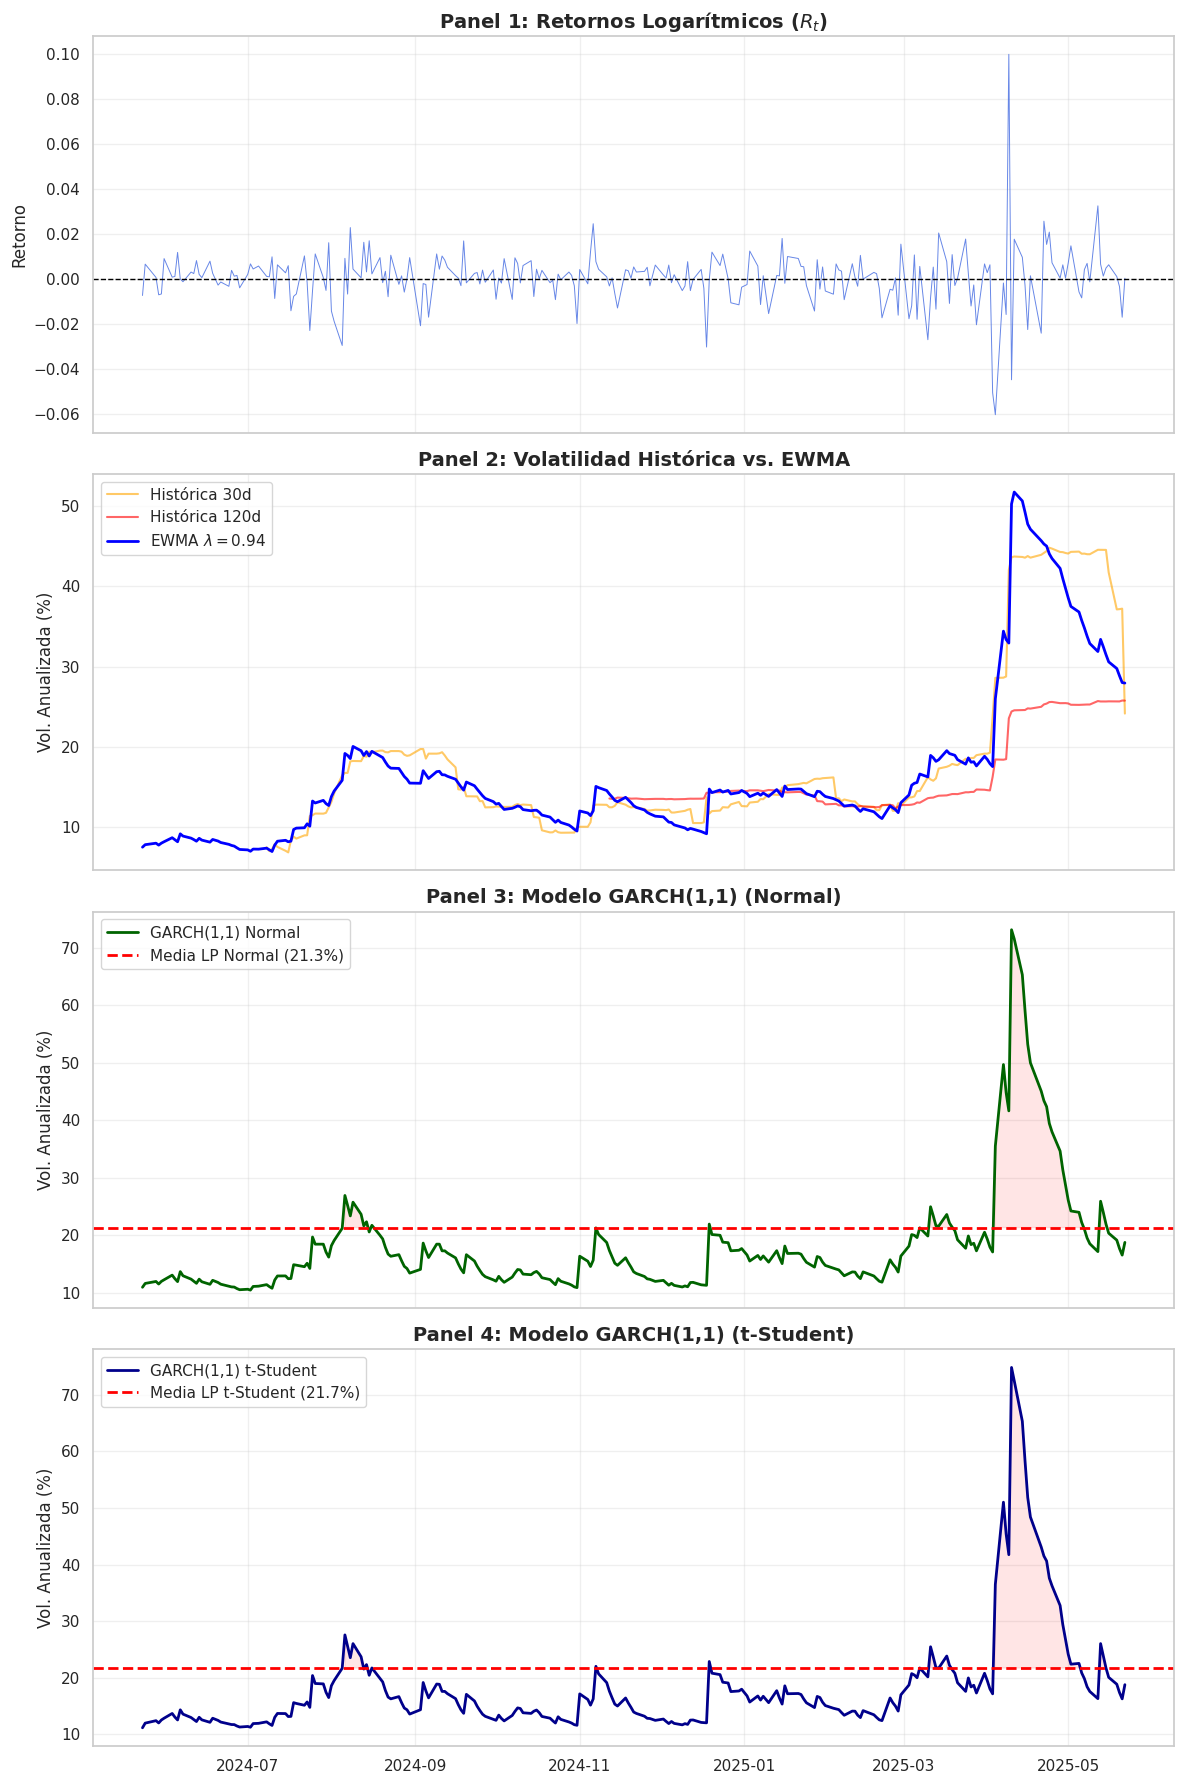

In [ ]:
# --- 6.2  Panel Cuádruple ---

# Creación del Panel Cuádruple
fig, ax = plt.subplots(4, 1, figsize=(12, 18), sharex=True)

# Panel 1: Retornos
ax[0].plot(retornos, color='royalblue', lw=0.7, alpha=0.8)
ax[0].axhline(0, color='black', lw=1, ls='--')
ax[0].set_title('Panel 1: Retornos Logarítmicos ($R_t$)', fontsize=14, fontweight='bold')
ax[0].set_ylabel('Retorno')
ax[0].grid(True, alpha=0.3)

# Panel 2: Histórica vs EWMA
ax[1].plot(vol_30 * 100, label='Histórica 30d', color='orange', alpha=0.6)
ax[1].plot(vol_120 * 100, label='Histórica 120d', color='red', alpha=0.6)
ax[1].plot(vol_ewma_94 * 100, label='EWMA $\lambda=0.94$', color='blue', lw=2)
ax[1].set_title('Panel 2: Volatilidad Histórica vs. EWMA', fontsize=14, fontweight='bold')
ax[1].set_ylabel('Vol. Anualizada (%)')
ax[1].legend(loc='upper left')
ax[1].grid(True, alpha=0.3)

# Panel 3: GARCH(1,1) Normal
ax[2].plot(vol_garch_anual * 100, label='GARCH(1,1) Normal', color='darkgreen', lw=2)
ax[2].axhline(vol_lp_anual * 100, color='red', ls='--', lw=2, label=f'Media LP Normal ({vol_lp_anual*100:.1f}%)')
ax[2].fill_between(vol_garch_anual.index, vol_lp_anual*100, vol_garch_anual*100, where=(vol_garch_anual > vol_lp_anual), color='red', alpha=0.1)
ax[2].set_title('Panel 3: Modelo GARCH(1,1) (Normal)', fontsize=14, fontweight='bold')
ax[2].set_ylabel('Vol. Anualizada (%)')
ax[2].legend(loc='upper left')
ax[2].grid(True, alpha=0.3)

# Panel 4: GARCH(1,1) t-Student
ax[3].plot(vol_garch_t_anual * 100, label='GARCH(1,1) t-Student', color='darkblue', lw=2)
ax[3].axhline(vol_lp_t_anual * 100, color='red', ls='--', lw=2, label=f'Media LP t-Student ({vol_lp_t_anual*100:.1f}%)')
ax[3].fill_between(vol_garch_t_anual.index, vol_lp_t_anual*100, vol_garch_t_anual*100, where=(vol_garch_t_anual > vol_lp_t_anual), color='red', alpha=0.1)
ax[3].set_title('Panel 4: Modelo GARCH(1,1) (t-Student)', fontsize=14, fontweight='bold')
ax[3].set_ylabel('Vol. Anualizada (%)')
ax[3].legend(loc='upper left')
ax[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## Tabla resumen comparativa de modelos

| Modelo | Ponderación | Reversión LP | Parámetros | Captura clustering |
|--------|-------------|-------------|-----------|-------------------|
| Histórica fija | Uniforme (ventana) | No | $T$ | No |
| Garman-Klass | Uniforme (ventana) | No | $T$ | No |
| EWMA | Exponencial | No ($\alpha+\beta=1$) | $\lambda$ | Parcialmente |
| GARCH(1,1) | Exponencial | **Sí** | $\omega, \alpha, \beta$ | **Sí** |